## The seaborn.boxplot() function creates a box plot to show distributions with respect to categories

**sns.boxplot(x, y, hue, data,color)**

* A Box Plot is also known as Whisker plot is created to display the summary of the set of data values having properties like minimum, first quartile, median, third quartile and maximum. 
* In the box plot, a box is created from the first quartile to the third quartile, a vertical line is also there which goes through the box at the median. Here x-axis denotes the data to be plotted while the y-axis shows the frequency distribution.


     Q1-1.5IQR   Q1   median  Q3   Q3+1.5IQR
                  |-----:-----|
  o      |--------|     :     |--------|    o  o
                  |-----:-----|
flier             <----------->            fliers
                       IQR

* x, y: These parameters take names of variables in data or vector data (lists, NumPy arrays, or pandas Series).
One variable is typically categorical, defining the groups along an axis.
The other is typically quantitative, defining the values for which the distribution is plotted.
Assigning to x creates vertical boxes, while assigning to y (and not x) creates horizontal boxes.
* hue: This is a categorical variable in data that determines which column should be used for color encoding, allowing for nested grouping and distinction between subgroups within the main categories defined by x or y. The boxes are "dodged" (shifted) along the categorical axis when hue is used to avoid overlap.
* data: This is the input dataset, most commonly a pandas DataFrame where columns are variables and rows are observations.
* color: This parameter sets a uniform color for all elements of the plot when hue is not used. Common color arguments are single letters like 'b' (blue), 'g' (green), 'r' (red), etc.. If you want different colors for different hue categories, you should use the palette argument instead. 

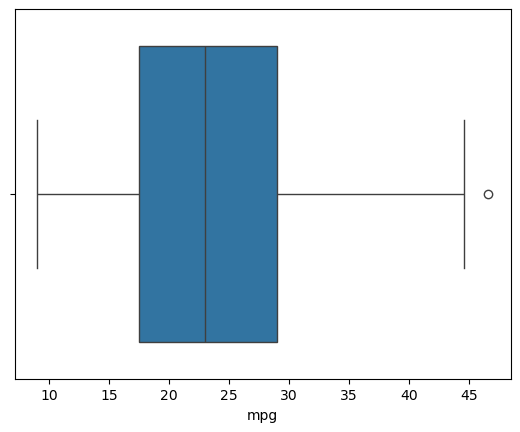

In [16]:
import pandas as pd
import seaborn as sns

df = pd.read_csv("auto-mpg.csv")
ax = sns.boxplot(x=df["mpg"])

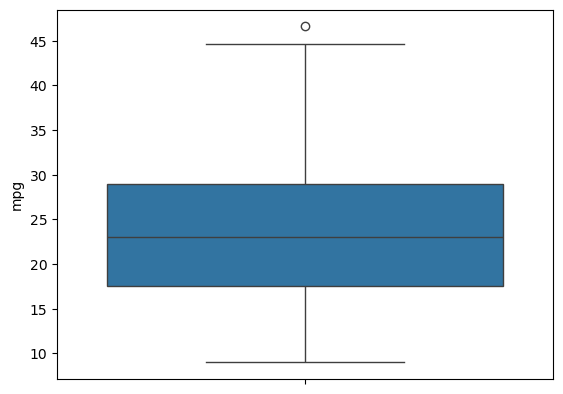

In [17]:
import pandas as pd
import seaborn as sns

df = pd.read_csv("auto-mpg.csv")
ax = sns.boxplot(y=df["mpg"])

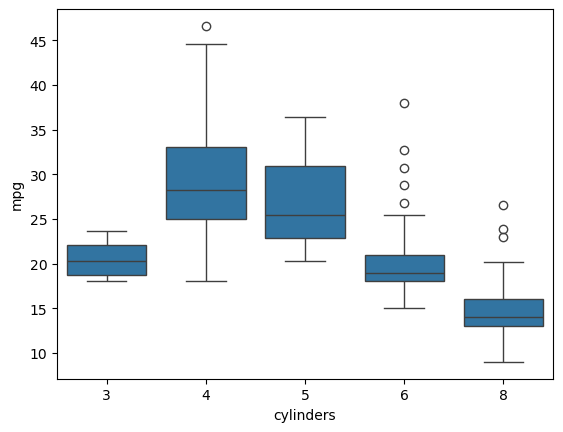

In [18]:
import pandas as pd
import seaborn as sns

df = pd.read_csv("auto-mpg.csv")
ax = sns.boxplot(y=df["mpg"], x=df["cylinders"])

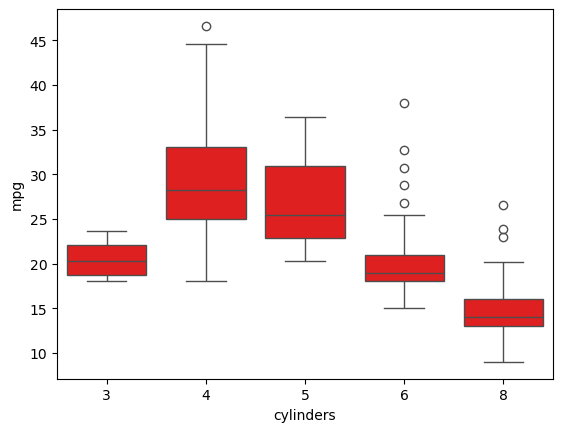

In [19]:
ax = sns.boxplot(y=df["mpg"], x=df["cylinders"],color="red")

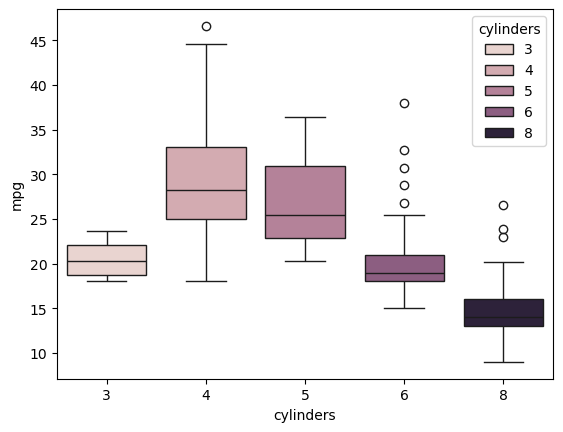

In [20]:
ax = sns.boxplot(y=df["mpg"], x=df["cylinders"], data=df, hue='cylinders')

## Detecting and Removing Outliers

C:\Users\LJENG\AppData\Local\Temp\ipykernel_9576\3422530202.py:21: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



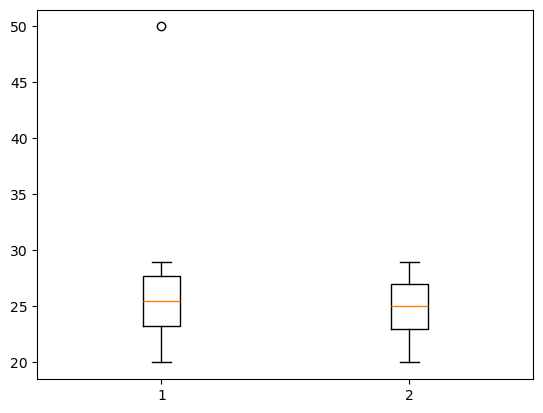

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
# Create a sample DataFrame
df = pd.DataFrame({'A': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                   'B': [20, 21, 23, 24, 25, 26, 27, 28, 29, 50]})

# Define a function to remove outliers using the interquartile range (IQR) method
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# Remove outliers from column B using the remove_outliers function
df_no_outliers = remove_outliers(df, 'B')

# Plot the data using a box plot
plt.boxplot([df['B'], df_no_outliers['B']])
ax.set_xticklabels(['Original', 'No Outliers'])
ax.set_title('Box plot with outliers removed')
plt.show()

## Detecting Outliers

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
# Create a sample DataFrame
df = pd.DataFrame({'A': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 25],
                   'B': [20, 21, 23, 24, 25, 26, 27, 28, 29, 50, 55]})

def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    ot = df[(df[col] <= lower_bound) | (df[col] >= upper_bound)]
    print(ot)

detect_outliers(df, 'B')

     A   B
9   10  50
10  25  55


## sns.scatterplot(x, y, hue, style, s , data) 
The sns.scatterplot function in Seaborn draws a scatter plot with semantic mapping, allowing for visualization of relationships between two variables (x,y) while grouping data by color (hue) and marker style (style). 

**Parameter Breakdown**
* x, y: Input data variables (column names in data or vectors).
* data: Pandas DataFrame or vector to use DataFlair.
* hue: Grouping variable (column name) that produces points with different colors.
* style: Grouping variable (column name) that produces points with different marker styles.
* s: Size of the markers; can be a constant or a column name for size mapping

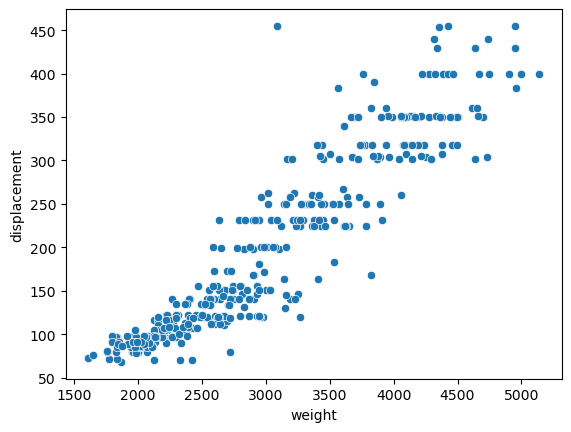

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("auto-mpg.csv")
sns.scatterplot(x="weight", y="displacement" ,data=df)
plt.show()

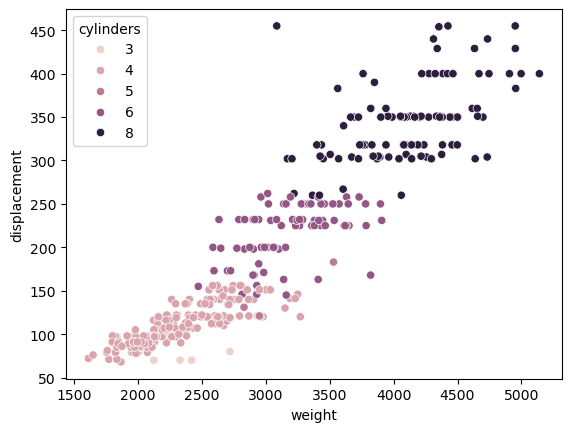

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("auto-mpg.csv")
sns.scatterplot(x="weight", y="displacement", hue='cylinders' ,data=df)
plt.show()

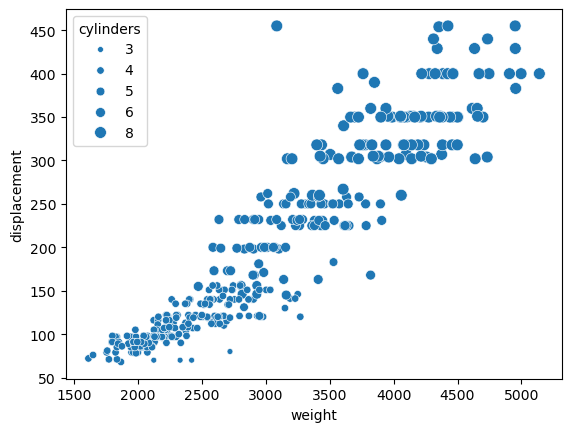

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("auto-mpg.csv")
sns.scatterplot(x="weight", y="displacement", data=df, size='cylinders')
plt.show()

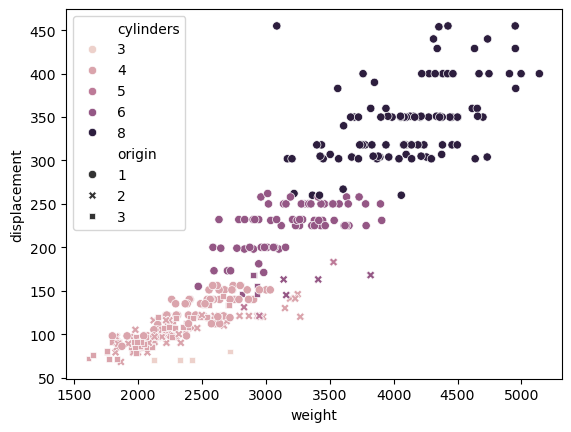

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("auto-mpg.csv")
sns.scatterplot(x="weight", y="displacement", data=df, style='origin',  hue='cylinders')
plt.show()

In [27]:
df.corr(numeric_only=True)

,mpg,cylinders,displacement,weight,acceleration,model year,origin
mpg,1.000000,-0.775396,-0.804203,-0.831741,0.420289,0.579267,0.563450
cylinders,-0.775396,1.000000,0.950721,0.896017,-0.505419,-0.348746,-0.562543
displacement,-0.804203,0.950721,1.000000,0.932824,-0.543684,-0.370164,-0.609409
weight,-0.831741,0.896017,0.932824,1.000000,-0.417457,-0.306564,-0.581024
acceleration,0.420289,-0.505419,-0.543684,-0.417457,1.000000,0.288137,0.205873
model year,0.579267,-0.348746,-0.370164,-0.306564,0.288137,1.000000,0.180662
origin,0.563450,-0.562543,-0.609409,-0.581024,0.205873,0.180662,1.000000


## seaborn.heatmap(data,  vmin=None, vmax=None, cmap=None, linewidths=0, linecolor=’white’,annot=True, cbar=True)

* data: The primary input for the heatmap. This parameter accepts a 2D dataset that can be converted into a NumPy ndarray, such as a Pandas DataFrame or a NumPy array.
* vmin, vmax: Optional floating-point values used to anchor the minimum and maximum values of the colormap range, respectively. If not specified, these limits are automatically inferred from the data's range.
* cmap: Optional parameter to specify the colormap, which can be a Matplotlib colormap name, a matplotlib colormap object, or a list of colors. This controls the mapping from data values to color space.
* linewidths: Optional parameter that takes a float value to define the width of the lines that divide each cell in the heatmap. The default is 0 (no lines).
* linecolor: Optional parameter to specify the color of the lines that separate the cells, used in conjunction with linewidths. The default color is 'white'.
* annot: Optional boolean or rectangular dataset. If set to True, the numerical data values will be written inside each cell, which can be very useful for data exploration.
* cbar: Optional boolean indicating whether to draw a color bar (colorbar) next to the plot, which displays the scale of the data-to-color mapping. The default is True.

The data to be plotted:



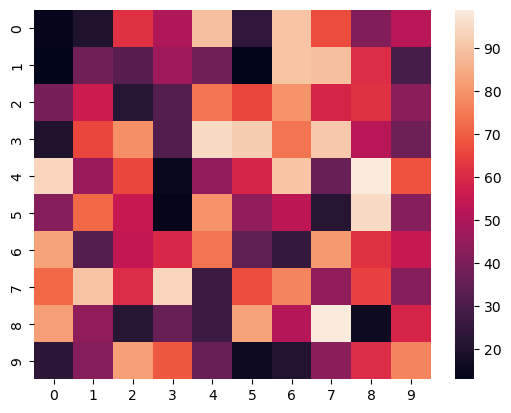

In [28]:
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
 
# generating 2-D 10x10 matrix of random numbers
# from 1 to 100
data = np.random.randint(low = 10,
                         high = 100,
                         size = (10, 10))
print("The data to be plotted:\n")

# plotting the heatmap
hm = sn.heatmap(data )
 
# displaying the plotted heatmap
plt.show()

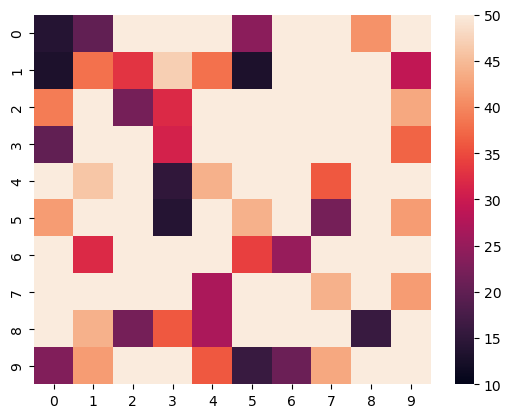

In [29]:
hm = sn.heatmap(data = data, vmin=10, vmax=50)
plt.show()

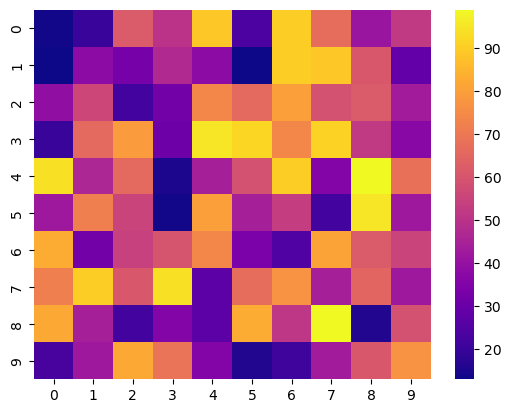

In [30]:
hm = sn.heatmap(data = data, cmap='plasma', cbar= True)
plt.show()

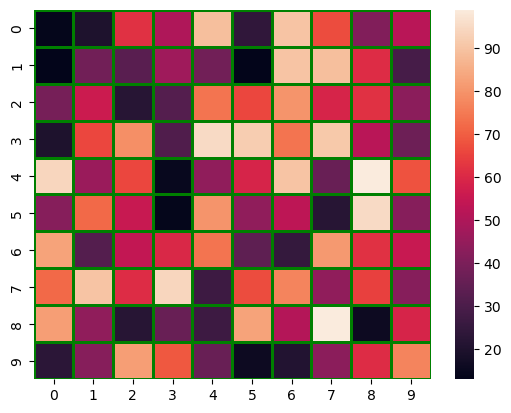

In [31]:
hm = sn.heatmap(data = data, linewidths=2, linecolor='green')
plt.show()

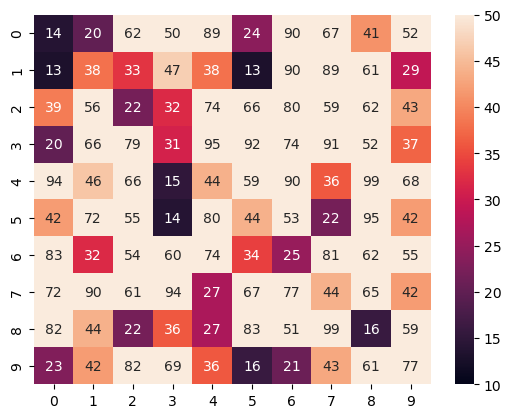

In [32]:
hm = sn.heatmap(data = data, vmin=10, vmax=50, annot=True)
plt.show()

# NetworkX
1. **nx.Graph():** Creates an undirected graph where edges do not have a specific direction. If an edge exists between node 1 and node 2, it can be traversed in both directions.
2. **nx.DiGraph():** Creates a directed graph, where all edges have a specific direction. An edge from node 1 to node 2 is distinct from an edge from node 2 to node 1. 
3. **add_node(1)**: This method adds a single node with the identifier 1 to the graph. Nodes can be any hashable Python object, such as numbers, strings, or tuples.
4. **add_edge(3, 1)**:  This method adds a single edge between nodes 3 and 1. If the specified nodes (3 and 1 in this case) do not already exist in the graph, they are automatically added.
5. **G.add_nodes_from(['A', 'B', 'C'])**: This method efficiently adds multiple nodes to the graph from an iterable container, such as a list.
6.  **G.add_edges_from([('A', 'B'), ('A', 'C'), ('B', 'C')])**: This method adds multiple edges from a container of edge-tuples. Each tuple represents a connection between two nodes. For nx.Graph(), these are undirected; for nx.DiGraph(), the order in the tuple (e.g., ('A', 'B')) defines the direction (from 'A' to 'B').
7.  **nx.draw(g,with_labels=True,node_size=1000, node_color='red', width=5, edge_color='blue')**: This function is used to visualize the graph using Matplotlib.


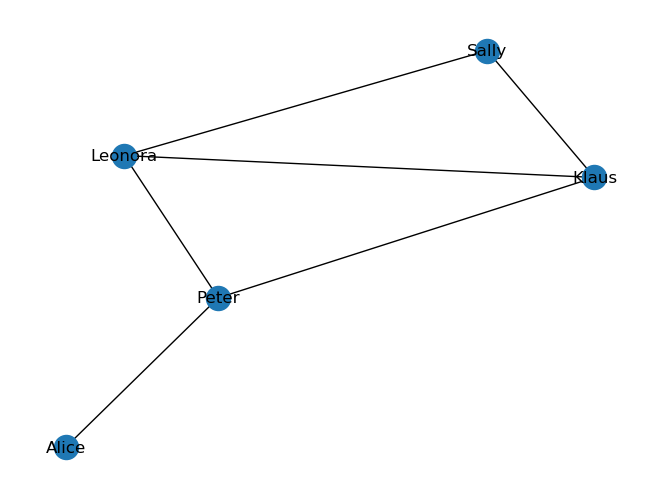

In [33]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Create an empty undirected graph
G = nx.Graph()

# 2. Add nodes and edges
G.add_node("Alice")
G.add_nodes_from(["Peter", "Sally", "Klaus", "Leonora"])
G.add_edge("Alice", "Peter")
G.add_edges_from([("Peter", "Klaus"), ("Klaus", "Leonora"), 
                  ("Klaus", "Sally"), ("Sally", "Leonora"), 
                  ("Leonora", "Peter")])

# 3. Draw the graph
nx.draw(G, with_labels=True)
plt.show()


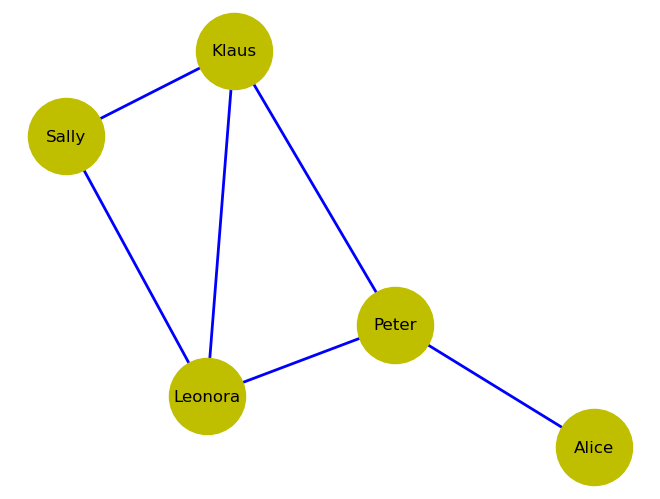

In [34]:
nx.draw(G,with_labels=True, node_size=3000, 
        node_color='y', width=2, 
        edge_color='blue')
plt.show()

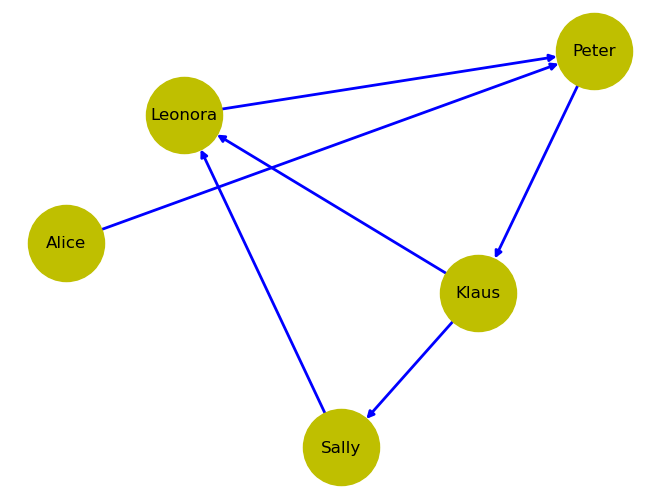

In [35]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Create an empty undirected graph
G = nx.DiGraph()

# 2. Add nodes and edges
G.add_node("Alice")
G.add_nodes_from(["Peter", "Sally", "Klaus", "Leonora"])
G.add_edge("Alice", "Peter")
G.add_edges_from([("Peter", "Klaus"), ("Klaus", "Leonora"), 
                  ("Klaus", "Sally"), ("Sally", "Leonora"), 
                  ("Leonora", "Peter")])

# 3. Draw the graph
nx.draw(G, with_labels=True,node_size=3000, node_color='y', 
        width=2, edge_color='blue')
plt.show()


# 139
The following dictionary shows how five people follow each other on Instagram:
 instagram = {'person1': [0,1,1,0,1], 'person2': [0,0,1,0,1], 'person3': [1,1,0,1,1],'person4': [1,1,1,0,0], 'person5': [1,1,0,0,0]}
 E.g., the list for person1 has the value on index 2 as 1 which means person1 followsperson3 and a directed edge should be
added from person1 to person3.

 Using networkx library, create a directed graph.

Directed Edges:
[('person1', 'person2'), ('person1', 'person3'), ('person1', 'person5'), ('person2', 'person3'), ('person2', 'person5'), ('person3', 'person1'), ('person3', 'person2'), ('person3', 'person4'), ('person3', 'person5'), ('person5', 'person1'), ('person5', 'person2'), ('person4', 'person1'), ('person4', 'person2'), ('person4', 'person3')]


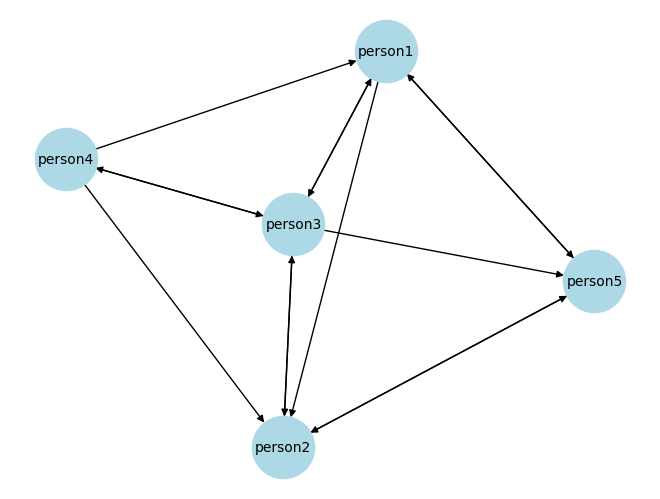

In [36]:
import networkx as nx

# Given dictionary
instagram = {
    'person1': [0,1,1,0,1],
    'person2': [0,0,1,0,1],
    'person3': [1,1,0,1,1],
    'person4': [1,1,1,0,0],
    'person5': [1,1,0,0,0]
}

# Create directed graph
G = nx.DiGraph()

# List of persons (to map indices)
persons = list(instagram.keys())

# Add edges
for person in instagram.keys():
    for i in range(len(persons)):
        if instagram[person][i] == 1:
            G.add_edge(person, persons[i])

# Print edges
print("Directed Edges:")
print(list(G.edges()))

# Draw graph
nx.draw(G, with_labels=True, node_color='lightblue', node_size=2000, font_size=10, arrows=True)


# Plotly
Plotly is a popular open-source Python library used for creating interactive, publication-quality visualizations. It is widely used in data science, analytics and machine learning for presenting data insights visually and interactively. It supports a wide variety of charts including line plots, scatter plots, bar charts, pie charts, heatmaps and 3D plots. It integrates well with Jupyter notebooks, Dash and web applications.

# Bar Chart

### px.bar(x, y, width, height, title, color, hover_data, pattern_shape, barmode, text_auto, text,
### orientation,color_discrete_map,color_discrete_sequence)


| Parameter                 | Example Value                  | Meaning                      |
| ------------------------- | ------------------------------ | ---------------------------- |
| `x`                       | `"Department"`                 | Category on X-axis           |
| `y`                       | `"Salary"`                     | Numerical values             |
| `width`                   | `800`                          | Chart width                  |
| `height`                  | `500`                          | Chart height                 |
| `title`                   | `"Department Salary Analysis"` | Chart title                  |
| `color`                   | `"Gender"`                     | Bars colored by category     |
| `hover_data`              | `["Experience"]`               | Extra info on mouse hover    |
| `pattern_shape`           | `"Gender"`                     | Pattern inside bars          |
| `barmode`                 | `"group"`                      | Bar arrangement              |
| `text_auto`               | `True`                         | Show numbers on bars         |
| `orientation`             | `"v"`                          | Vertical bars                |
| `color_discrete_map`      | dictionary                     | Custom colors for categories |
| `color_discrete_sequence` | list                           | Color order                  |


In [37]:
import plotly.express as px
import pandas as pd

# Sample data using a dictionary to create a pandas DataFrame
data = {
    'Category': ['A', 'B', 'C', 'A', 'B', 'C'],
    'Values': [10, 20, 15, 12, 18, 17],
    'Details': ['Info A1', 'Info B1', 'Info C1', 'Info A2', 'Info B2', 'Info C2'],
    'Region': ['East', 'West', 'East', 'West', 'East', 'West'],
    'Color_Col': ['color1', 'color2', 'color1', 'color2', 'color1', 'color2']
}
df = pd.DataFrame(data)

# Define a specific color map for the 'Color_Col' column
custom_color_map = {
    'e': 'red',
    'w': 'orange'
}

# Create the bar chart with multiple parameters
fig = px.bar(
    df,
    x="Category",
    y="Values",
    color="Region"   ,          # Color the bars based on the 'Color_Col' column
    title="Bar chart:",               # Set the chart title
    orientation="v",                  # Set orientation to vertical (default, but explicit)
    height=400,                       # Set the height of the figure in pixels
    width=600,                        # Set the width of the figure in pixels    
    barmode="group",                  # Group bars beside each other (instead of default 'relative'/'stack')  
    color_discrete_map=custom_color_map# Use the custom color map  
)

# Display the figure
fig.show()


In [38]:
import plotly.express as px
import pandas as pd

# Sample data using a dictionary to create a pandas DataFrame
data = {
    'Category': ['A', 'B', 'C', 'A', 'B', 'C'],
    'Values': [10, 20, 15, 12, 18, 17],
    'Details': ['Info A1', 'Info B1', 'Info C1', 'Info A2', 'Info B2', 'Info C2'],
    'Region': ['East', 'West', 'East', 'West', 'East', 'West'],
    'Color_Col': ['color1', 'color2', 'color1', 'color2', 'color1', 'color2']
}
df = pd.DataFrame(data)

# Define a specific color map for the 'Color_Col' column
custom_color_map = {
    'e': 'red',
    'w': 'orange'
}

# Create the bar chart with multiple parameters
fig = px.bar(
    df,
    x="Category",
    y="Values",
    color="Region"   ,          # Color the bars based on the 'Color_Col' column
    title="Bar chart:",               # Set the chart title
    orientation="v",                  # Set orientation to vertical (default, but explicit)
    height=400,                       # Set the height of the figure in pixels
    width=600,                        # Set the width of the figure in pixels
    hover_data=["Details", "Region"], # Add extra data to the hover tooltip
    pattern_shape="Region",           # Add different patterns based on the 'Region' column
    barmode="group",                  # Group bars beside each other (instead of default 'relative'/'stack')
    text_auto=True,                   # Automatically display values on the bars
    color_discrete_map=custom_color_map,# Use the custom color map
    color_discrete_sequence=["lightblue", "green"]# Fallback color sequence (overridden by map if keys match)
)

# Display the figure
fig.show()


# scatter

### Syntax:
px.scatter(
    data_frame,
    x,
    y,
    width,
    height,
    title,
    color,    
    size,
    color_discrete_map,
    color_discrete_sequence,
    symbol,
    facet_col,
    facet_row
)

| Parameter                 | Example Value                    | Purpose                            |
| ------------------------- | -------------------------------- | ---------------------------------- |
| `x`                       | `"Hours_Studied"`                | X-axis variable                    |
| `y`                       | `"Marks"`                        | Y-axis variable                    |
| `width`                   | `900`                            | Chart width                        |
| `height`                  | `500`                            | Chart height                       |
| `title`                   | `"Student Performance Analysis"` | Chart title                        |
| `color`                   | `"Gender"`                       | Groups points by color             |
| `size`                    | `"Attendance"`                   | Bubble size                        |
| `color_discrete_map`      | dictionary                       | Custom colors for categories       |
| `color_discrete_sequence` | list                             | Order of colors                    |
| `symbol`                  | `"Gender"`                       | Marker shape                       |
| `facet_col`               | `"Department"`                   | Creates multiple columns of charts |
| `facet_row`               | `"Gender"`                       | Creates multiple rows of charts    |


In [39]:
import pandas as pd
import plotly.express as px
data = {
    "Hours": [2,3,4,5,6,7],
    "Marks": [40,50,60,65,70,80],
    "Gender": ["Male","Female","Male","Female","Male","Female"]
}

df = pd.DataFrame(data)

fig = px.scatter(
    df,
    x="Hours",
    y="Marks",
    color="Gender",
    size="Marks",
    symbol="Gender",
    title="Study Hours vs Marks"
)

fig.show()

In [44]:
data = {
    "Hours": [2,3,4,5,6],
    "Marks": [40,50,60,70,80],
    "Attendance": [60,65,70,80,90]
}
df = pd.DataFrame(data)

fig = px.scatter_3d(
    df,
    x="Hours",
    y="Marks",
    z="Attendance",
    color="Marks",
    title="3D Scatter Plot"
)

fig.show()

In [53]:
import pandas as pd
import plotly.express as px

data = {
    "Hours_Studied": [2,3,4,5,6,7,8,3,5],
    "Marks": [40,50,55,65,70,80,85,48,68],
    "Gender": ["Male","Female","Male","Female","Male","Female","Male",
               "Female","Male"],
    "Attendance": [60,70,75,80,85,90,95,72,88],
    "Department": ["IT","IT","HR","HR","Finance","Finance","IT","HR","Finance"]
}

df = pd.DataFrame(data)
fig = px.scatter(
    df,
    x="Hours_Studied",
    y="Marks",
    width=900,
    height=500,
    title="Student Performance Analysis",
    
    color="Gender",                 # grouping by color
    size="Attendance",              # bubble size
    
    color_discrete_map={
        "Malle": "green",
        "Female": "red"
    },
    
    color_discrete_sequence=["blue","red"],
    
    symbol="Gender",                # different marker shapes
    
    facet_col="Department",         # separate charts by column
    facet_row="Gender"              # separate charts by row
)

fig.show()

In [55]:
fig = px.scatter_matrix(
    df,
    dimensions=["Hours_Studied","Marks","Attendance"],
    color="Marks",
    title="Scatter Matrix",
    width=500,
    height=100
)

fig.show()

# line chart

### Syntax
px.line(
    df,
    x,
    y,
    color,
    markers,
    hover_data,
    color_discrete_map,
    title,    
    color_discrete_sequence
)

In [57]:
data = {
    "Month": ["Jan","Feb","Mar","Apr"],
    "Sales": [100,150,130,170]
}

df = pd.DataFrame(data)

fig = px.line(
    df,
    x="Month",
    y="Sales",
    markers=True,
    title="Monthly Sales"
)

fig.show()

In [58]:
import pandas as pd
import plotly.express as px

data = {
    "Month": ["Jan","Feb","Mar","Apr","Jan","Feb","Mar","Apr"],
    "Sales": [100,120,140,160,90,110,130,150],
    "Region": ["North","North","North","North",
               "South","South","South","South"],
    "Profit": [20,25,30,35,18,22,27,32]
}

df = pd.DataFrame(data)
fig = px.line(
    df,
    x="Month",
    y="Sales",
    color="Region",
    markers=True,
    width=800,
    height=500,
    title="Monthly Sales Comparison",
    hover_data=["Profit"],
    color_discrete_sequence=["blue","red"]
)

fig.show()

# histogram

A Histogram shows the distribution or frequency of numerical data.

Example: distribution of marks, salary, age etc.

px.histogram(df, x, y, nbins, color, histfunc, pattern_shape, text_auto, 

             color_discrete_map, color_discrete_sequence)

| Parameter                 | Meaning                                    |
| ------------------------- | ------------------------------------------ |
| `x`                       | Numerical variable                         |
| `y`                       | Optional value column                      |
| `nbins`                   | Number of bins (bars)                      |
| `color`                   | Grouping by category                       |
| `histfunc`                | Aggregation method (`count`, `sum`, `avg`) |
| `pattern_shape`           | Pattern style in bars                      |
| `text_auto`               | Display values on bars                     |
| `color_discrete_map`      | Custom color mapping                       |
| `color_discrete_sequence` | Color order                                |


In [64]:
import plotly.express as px
import pandas as pd
data = {
    "Marks":[40,42,52,55,60,65,70,75,80,85,40,45,70],
    "Gender":["Male","Female","Male","Female","Male",
              "Female","Male","Female","Male","Female","Male","Female","Male"],
     "SPI":[1,2,3,4,5,6,7,8,9,10,11,12,13],
}

df = pd.DataFrame(data)
fig = px.histogram(
    df,
    x="Marks",
    y="SPI",
   
    nbins=5,
    color="Gender",
    histfunc="sum",
    pattern_shape="Gender",
    text_auto=False,
    color_discrete_map={"Male":"blue","Female":"pink"},
    color_discrete_sequence=["blue","pink"]
)

fig.show()

# Pie Chart
### Syntax
fig = px.pie(data, values, names, color_discrete_sequence, title)


| Parameter                 | Meaning                              |
| ------------------------- | ------------------------------------ |
| `data`                    | DataFrame containing data            |
| `values`                  | Numerical values used for slice size |
| `names`                   | Category names                       |
| `color_discrete_sequence` | List of colors for slices            |
| `title`                   | Chart title                          |


In [71]:
import pandas as pd
import plotly.express as px

data = {
    "Department": ["IT", "HR", "Finance", "Marketing"],
    "Employees": [40, 20, 25, 15]
}

df = pd.DataFrame(data)
fig = px.pie(
    df,
    values="Employees",
    names="Department",
    color_discrete_sequence=["blue", "green", "orange", "red"],
    title="Employee Distribution by Department"
)

fig.show()

In [ ]:
import pandas as pd
import plotly.express as px

data = {
    "Department": ["IT", "HR", "Finance", "Marketing"],
    "Employees": [40, 20, 25, 15]
}

df = pd.DataFrame(data)

fig = px.pie(
    df,
    values="Employees",
    names="Department",
    color_discrete_sequence=["blue", "green", "orange", "red"],
    title="Employee Distribution by Department"
)

fig.update_traces(
    textinfo="percent+label",
    textposition="inside",
    pull=[0,0.1,0,0]
)

fig.show()